# Лабораторная работа 3 (Вариат 13)
**Тема.** ВЫЧИСЛЕНИЕ ПРОИЗВОДНЫХ И ИНТЕГРАЛОВ

Для каждого варианта задан интервал $[a, b]$, функция $f(x)$ и указан метод вычисления интеграла. Вначале вычислить точные выражения для первой, второй производных $\frac{df(x)}{dx}, \frac{d^2f(x)}{dx^2}$ и для интеграла. Затем необходимо составить подпрограмму для вычисления первой и второй производных по формулам:
$$
\frac{df(x_2)}{dx}=\Lambda^{3}_{1}[f(x_2)]=\frac{y_3-y_1}{2h}
$$

$$
\frac{d^2f}{dx^2} ≈ \frac{d^2P_2}{dx^2} = \Lambda_{2}[f(x)] = \frac{y_1-2y_2+y_3}{h^2}; x_1 \le x \le x_3,
$$
и подпрограмму вычисления интеграла указанным методом. Составить основную программу, которая вычисляет таблицу значений функции, ее точных и приближенных производных $f, f', \Lambda_{1}^{3}f, f'', \Lambda_{2}^{3}f$ в точках $x_j=a+\frac{(j-1)\cdot (b-a)}{20}; j=1..21$ а также точное и приближенное значения интеграла. Расчет первой производной в крайних точках a и b выполнить по формулам:

$$
\frac{df(x_1)}{dx}=\Lambda^{3}_{1}[f(x_1)]=\frac{3y_1-4y_2+y_3}{2h}
$$

$$
\frac{df(x_3)}{dx}=\Lambda^{3}_{1}[f(x_3)]=\frac{y_1-4y_2+3y_3}{2h}
$$

соответственно, вторую производную вычислять только во внутренних точках.
    Расчеты производной произвести для $h_p = 0.2, 0.1, и 0.05$. Расчеты интеграла произвести для $m=10, 20 и 40$.
    При использовании алгоритма вычисления интеграла с автоматическим выбором шага по данной точности расчет произвести для $\delta = 0.1, 0.01, 0.001$ и получить зависимость $m(\delta)$.
    Проанализировать погрешность вычислений, для чего построить графики и вычислить погрешности производных и интеграла.
    Учесть, что $\int{f(x)dx} = 3.533$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = 1
b = 7
exact_integral_val = 3.533

def f(x):
    return np.sin(x)**2 - 3 * np.cos(x)

def df_exact(x):
    return np.sin(2*x) + 3*np.sin(x)

def d2f_exact(x):
    return 2*np.cos(2*x) + 3*np.cos(x)

Сразу введем подпрограмму производных

In [2]:
def compute_derivatives(x_arr, h):
    y = f(x_arr)
    n = len(x_arr)
    df = np.zeros(n)
    d2f = np.zeros(n)
    
    for i in range(n):
        if i == 0: # Левая граница
            df[i] = (-3*y[i] + 4*y[i+1] - y[i+2]) / (2*h) # Формула для x1
            d2f[i] = np.nan # По условию только во внутренних
        elif i == n - 1: # Правая граница
            df[i] = (y[i-2] - 4*y[i-1] + 3*y[i]) / (2*h) # Формула для x3
            d2f[i] = np.nan
        else: # Внутренние точки
            df[i] = (y[i+1] - y[i-1]) / (2*h)
            d2f[i] = (y[i-1] - 2*y[i] + y[i+1]) / (h**2)
    return df, d2f

И подпрограмму интеграла (квадратурная формула средних)

In [3]:
def midpoint_integral(a, b, m):
    h = (b - a) / m
    x_mid = np.linspace(a + h/2, b - h/2, m)
    return np.sum(f(x_mid)) * h

Основной расчет таблицы $(n=21)$

In [4]:
n_points = 21
x_table = np.linspace(a, b, n_points)
h_table = (b - a) / (n_points - 1)
df_approx, d2f_approx = compute_derivatives(x_table, h_table)

print(f"{'x':>5} | {'f(x)':>7} | {'f_exact':>8} | {'df_appr':>8} | {'d2f_ex':>8} | {'d2f_app':>8}")
print("-" * 65)
for i in range(n_points):
    print(f"{x_table[i]:5.2f} | {f(x_table[i]):7.3f} | {df_exact(x_table[i]):8.3f} | {df_approx[i]:8.3f} | {d2f_exact(x_table[i]):8.3f} | {d2f_approx[i]:8.3f}")

    x |    f(x) |  f_exact |  df_appr |   d2f_ex |  d2f_app
-----------------------------------------------------------------
 1.00 |  -0.913 |    3.434 |    3.593 |    0.789 |      nan
 1.30 |   0.126 |    3.406 |    3.333 |   -0.911 |   -0.866
 1.60 |   1.087 |    2.940 |    2.899 |   -2.084 |   -2.024
 1.90 |   1.865 |    2.227 |    2.221 |   -2.552 |   -2.498
 2.20 |   2.419 |    1.474 |    1.494 |   -2.380 |   -2.349
 2.50 |   2.762 |    0.836 |    0.866 |   -1.836 |   -1.835
 2.80 |   2.939 |    0.374 |    0.396 |   -1.276 |   -1.300
 3.10 |   2.999 |    0.042 |    0.045 |   -1.004 |   -1.041
 3.40 |   2.966 |   -0.273 |   -0.290 |   -1.162 |   -1.191
 3.70 |   2.825 |   -0.691 |   -0.720 |   -1.667 |   -1.674
 4.00 |   2.534 |   -1.281 |   -1.305 |   -2.252 |   -2.229
 4.30 |   2.042 |   -2.014 |   -2.016 |   -2.560 |   -2.511
 4.60 |   1.324 |   -2.758 |   -2.727 |   -2.286 |   -2.226
 4.90 |   0.406 |   -3.314 |   -3.248 |   -1.301 |   -1.250
 5.20 |  -0.625 |   -3.478 |   -3.

Анализ производных для разных $h$

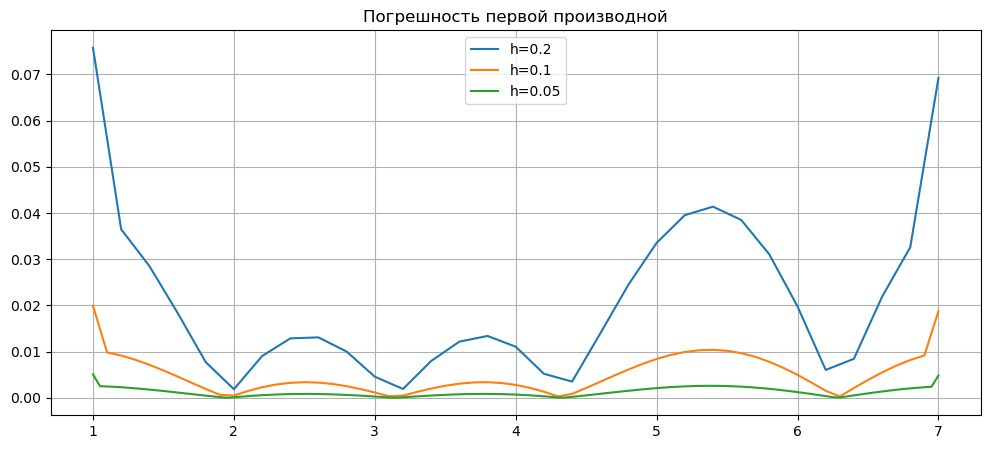

In [5]:
h_values = [0.2, 0.1, 0.05]
plt.figure(figsize=(12, 5))

for h in h_values:
    x_range = np.arange(a, b + h/2, h)
    df_app, _ = compute_derivatives(x_range, h)
    error = np.abs(df_app - df_exact(x_range))
    plt.plot(x_range, error, label=f'h={h}')

plt.title('Погрешность первой производной')
plt.legend()
plt.grid(True)
plt.show()

Расчет интеграла для $m = 10, 20, 40$

In [6]:
print("\nРасчет интеграла:")
for m in [10, 20, 40]:
    val = midpoint_integral(a, b, m)
    err = abs(val - exact_integral_val)
    print(f"m={m}: Значение={val:.5f}, Погрешность={err:.5e}")


Расчет интеграла:
m=10: Значение=3.54024, Погрешность=7.24258e-03
m=20: Значение=3.53490, Погрешность=1.89844e-03
m=40: Значение=3.53357, Погрешность=5.68450e-04


Теперь реализуем схему с автоматическим выбором шага по заданной точности

In [7]:
def integral_with_eps(a, b, delta):
    m = 2
    old_val = midpoint_integral(a, b, m)
    while True:
        m *= 2
        new_val = midpoint_integral(a, b, m)
        if abs(new_val - old_val) / 3 < delta:
            return new_val, m
        old_val = new_val

print("\nЗависимость m от delta:")
for delta in [0.1, 0.01, 0.001]:
    res, m_needed = integral_with_eps(a, b, delta)
    print(f"Delta={delta}: m={m_needed}, Result={res:.5f}")


Зависимость m от delta:
Delta=0.1: m=4, Result=3.57839
Delta=0.01: m=16, Result=3.53590
Delta=0.001: m=32, Result=3.53382
